--- One-Sample Z-Test: Current Recency vs. 45-Day Benchmark ---

Historical Mean (mu): 45.00 days
Current Sample Mean: 49.11 days (n=2240)
-----------------------------------------------------------------
Calculated Z-Statistic: 7.7796
P-value (Two-tailed): 0.0000

--- Conclusion ---
Conclusion: **Reject the Null Hypothesis** (p < 0.05).
Interpretation: The current customer base has a significantly **HIGHER** average Recency (i.e., they are **less recently engaged**). ⚠️
-----------------------------------------------------------------


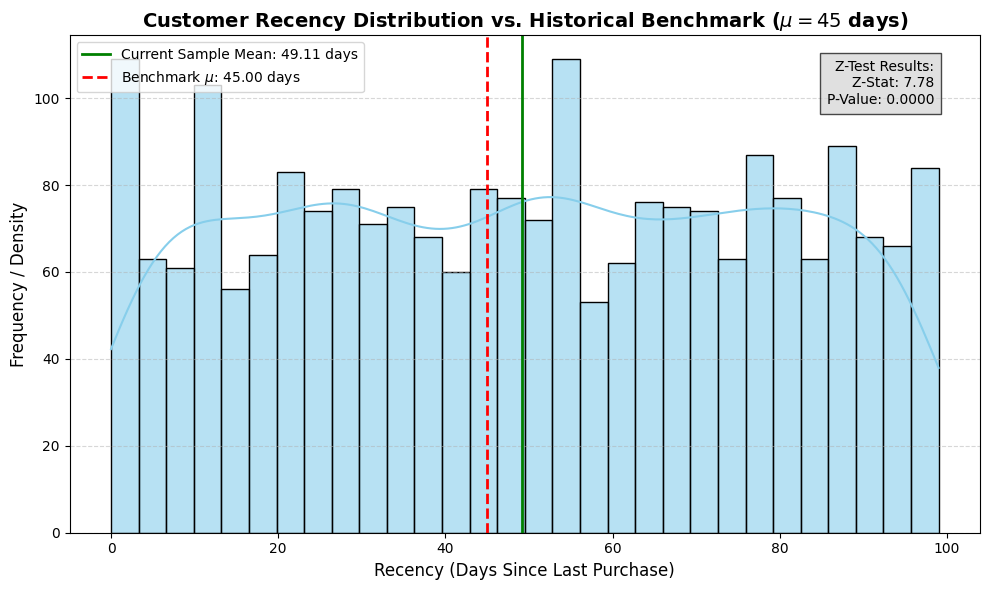

In [ ]:
import pandas as pd
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('marketing_campaign.tsv', sep='\t')
except FileNotFoundError:
    print("ERROR: Please ensure 'marketing_campaign.csv' is in the correct directory.")
    raise 

df.columns = df.columns.str.strip().str.replace(' ', '_') 
df_clean = df.dropna(subset=['Recency']).copy()
sample_data = df_clean['Recency']

POP_MEAN_MU = 45.0
POP_STD_SIGMA = 25.0

sample_mean = sample_data.mean()
sample_size_n = len(sample_data)

standard_error = POP_STD_SIGMA / np.sqrt(sample_size_n)
z_score = (sample_mean - POP_MEAN_MU) / standard_error
p_value = stats.norm.sf(abs(z_score)) * 2 

print("--- One-Sample Z-Test: Current Recency vs. 45-Day Benchmark ---")
print(f"\nHistorical Mean (mu): {POP_MEAN_MU:.2f} days")
print(f"Current Sample Mean: {sample_mean:.2f} days (n={sample_size_n})")
print("-" * 65)

print(f"Calculated Z-Statistic: {z_score:.4f}")
print(f"P-value (Two-tailed): {p_value:.4f}")

alpha = 0.05
print("\n--- Conclusion ---")
if p_value < alpha:
    print("Conclusion: **Reject the Null Hypothesis** (p < 0.05).")
    if sample_mean < POP_MEAN_MU:
        print("Interpretation: The current customer base has a significantly **LOWER** average Recency (i.e., they are **more recently engaged**). 🎉")
    else:
        print("Interpretation: The current customer base has a significantly **HIGHER** average Recency (i.e., they are **less recently engaged**). ⚠️")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (p > 0.05).")
    print("Interpretation: Customer engagement (Recency) is holding steady compared to the benchmark.")
print("-" * 65)

plt.figure(figsize=(10, 6))

sns.histplot(sample_data, kde=True, bins=30, color='skyblue', edgecolor='black', alpha=0.6)

plt.axvline(sample_mean, color='green', linestyle='-', linewidth=2, 
            label=f'Current Sample Mean: {sample_mean:.2f} days')

plt.axvline(POP_MEAN_MU, color='red', linestyle='--', linewidth=2, 
            label=f'Benchmark $\mu$: {POP_MEAN_MU:.2f} days')

plt.text(
    0.95, 
    0.95, 
    f"Z-Test Results:\nZ-Stat: {z_score:.2f}\nP-Value: {p_value:.4f}",
    transform=plt.gca().transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    bbox={'facecolor': 'lightgray', 'alpha': 0.7, 'pad': 5}
)

plt.title("Customer Recency Distribution vs. Historical Benchmark ($\mu=45$ days)", fontsize=14, fontweight='bold')
plt.xlabel("Recency (Days Since Last Purchase)", fontsize=12)
plt.ylabel("Frequency / Density", fontsize=12)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()